# Hotel Booking Cancellation · v2 · calibration and cost-based threshold (T3)

XGBoost stays the final model (T2). Two questions are left before its probabilities can drive an action.
First, **are the probabilities honest?** When the model says 0.3, do about 30% of those bookings cancel?
Second, **where should the hotel act?** Flagging a booking costs something, and catching a cancellation
is worth something. The right threshold depends on those amounts, not on F1.

Everything is built from XGBoost's saved out-of-fold (OOF) probabilities. No model is refit. Every
calibrator and threshold is chosen on the other four outer folds and scored on fold k (rule B3).
`test.csv` is not opened.

In [1]:
import hashlib
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

from sklearn.calibration import calibration_curve
from sklearn.isotonic import IsotonicRegression
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import average_precision_score, brier_score_loss, precision_score, recall_score, f1_score

np.random.seed(42)
palette = ['#2B5C8F', '#E05A47', '#6A9F58', '#9C755F']
data = Path('../../data/processed/v2')
results = Path('../../reports/results/v2')

## 1. Training rows, saved folds and the manifest check

In [2]:
# the files must be the ones the v2 manifest froze; test.csv is never read here
manifest = json.load(open(data / 'manifest.json'))
for name in ['train.csv', 'cv_folds.csv']:
    digest = hashlib.sha256((data / name).read_bytes()).hexdigest()
    assert digest == manifest['files'][name], f'{name} does not match the manifest'

train = pd.read_csv(data / 'train.csv', usecols=['hotel', 'adr', 'total_nights', 'is_canceled'])
folds = pd.read_csv(data / 'cv_folds.csv', usecols=['row_id', 'outer_fold'])
assert (folds.row_id.to_numpy() == np.arange(len(train))).all()
print('train rows:', len(train), f' cancel rate {train.is_canceled.mean():.4f}')
folds.groupby('outer_fold').size().rename('rows').to_frame().T

train rows: 67974  cancel rate 0.2775


outer_fold,0,1,2,3,4
rows,13595,13594,13595,13595,13595


Both hashes match the manifest, so these are the same 67,974 rows and five outer folds (13,594–13,595 rows each, cancel rate 0.2775) that every v2 model was scored on. Only four columns of `train.csv` are read: `hotel`, `adr`, `total_nights` and the label.

## 2. XGBoost's out-of-fold probabilities, joined to the booking value columns

In [3]:
xgb = pd.read_csv(results / 'oof' / 'xgboost.csv')
assert list(xgb.columns) == ['row_id', 'outer_fold', 'is_canceled', 'proba']
assert len(xgb) == len(train) and xgb.row_id.is_unique

# row_id is the 0-based row of train.csv
df = (train.rename_axis('row_id').reset_index()
      .merge(folds, on='row_id', validate='one_to_one')
      .merge(xgb.rename(columns={'outer_fold': 'fold_oof', 'is_canceled': 'y_oof'}),
             on='row_id', how='left', validate='one_to_one'))
assert (df.fold_oof == df.outer_fold).all(), 'outer_fold disagrees with cv_folds.csv'
assert (df.y_oof == df.is_canceled).all(), 'is_canceled disagrees with train.csv'
assert df.proba.between(0, 1).all()

df = df[['row_id', 'outer_fold', 'hotel', 'adr', 'total_nights', 'is_canceled', 'proba']]
y, fold, p_raw = df.is_canceled.to_numpy(), df.outer_fold.to_numpy(), df.proba.to_numpy()
df.head()

,row_id,outer_fold,hotel,adr,total_nights,is_canceled,proba
0,0,4,Resort Hotel,0.0,0,0,0.031870
1,1,0,Resort Hotel,0.0,0,0,0.066513
2,2,0,Resort Hotel,75.0,1,0,0.012367
3,3,4,Resort Hotel,98.0,2,0,0.053322
4,4,2,Resort Hotel,107.0,2,0,0.032373


The XGBoost OOF file holds one probability for each of the 67,974 training rows. Its `outer_fold` and `is_canceled` agree exactly with `cv_folds.csv` and `train.csv`. Each probability came from the model tuned and fitted without that row's outer fold, so it is an honest out-of-sample prediction.

## 3. The value at stake in each booking

The cost scenario needs a euro value per booking. Here it is the room revenue on the books,
`V = adr × total_nights`. Day-use bookings (0 nights) have V = 0. A handful of rows have a negative
`adr`, and their V is floored at 0.

In [4]:
df['V'] = (df.adr * df.total_nights).clip(lower=0)
V = df.V.to_numpy()

value = pd.DataFrame({
    'all bookings': df.V.describe(percentiles=[.25, .5, .75, .95]),
    'cancelled': df.V[y == 1].describe(percentiles=[.25, .5, .75, .95]),
    'not cancelled': df.V[y == 0].describe(percentiles=[.25, .5, .75, .95]),
}).T.round(1)
print('day-use rows (V = 0 from 0 nights):', int((df.total_nights == 0).sum()),
      ' negative adr rows:', int((df.adr < 0).sum()))
value

day-use rows (V = 0 from 0 nights): 460  negative adr rows: 0


,count,mean,std,min,25%,50%,75%,95%,max
all bookings,67974.0,398.4,371.5,0.0,155.0,300.0,506.6,1127.0,7590.0
cancelled,18860.0,480.0,423.2,0.0,214.0,364.5,596.7,1300.0,6148.0
not cancelled,49114.0,367.1,344.6,0.0,138.0,280.0,475.2,1034.0,7590.0


A typical booking puts about €300 of room revenue on the books (median; mean €398, heavily right-skewed up to €7,590). Cancelled bookings are worth more than kept ones: median €365 vs €280. 460 day-use rows have V = 0, so no rule will ever flag them. No `adr` is negative in the v2 training rows. **This matters for everything below:** at r = 0.25, catching an average cancellation recovers about €120, which is 24 times the €5 contact cost in the base case.

# Part 1 — Calibration

## 4. How well calibrated is raw XGBoost?

The Brier score is the mean squared gap between the probability and the 0/1 outcome, and lower is
better. For reference, a model that always predicts the cancel rate scores `rate × (1 − rate)`.

In [5]:
def per_fold(metric, p):
    return np.array([metric(y[fold == k], p[fold == k]) for k in range(5)])

brier_raw = per_fold(brier_score_loss, p_raw)
base_rate = y.mean()
pd.DataFrame({
    'brier_raw': brier_raw,
    'brier_constant': [y[fold == k].mean() * (1 - y[fold == k].mean()) for k in range(5)],
    'mean_p': [p_raw[fold == k].mean() for k in range(5)],
    'cancel_rate': [y[fold == k].mean() for k in range(5)],
}, index=pd.Index(range(5), name='outer_fold')).round(4).T.assign(
    pooled=[brier_score_loss(y, p_raw), base_rate * (1 - base_rate), p_raw.mean(), base_rate]).round(4)

outer_fold,0,1,2,3,4,pooled
brier_raw,0.1164,0.1150,0.1180,0.1182,0.1203,0.1176
brier_constant,0.2005,0.2005,0.2005,0.2005,0.2005,0.2005
mean_p,0.2732,0.2735,0.2722,0.2741,0.2705,0.2727
cancel_rate,0.2775,0.2775,0.2775,0.2775,0.2775,0.2775


Raw XGBoost scores a pooled Brier of **0.1176**, against 0.2005 for a constant guess at the cancel rate, so it removes about 41% of the squared error. The fold spread is small (0.1150–0.1203, SD 0.0020). The mean probability, 0.2727, sits just under the cancel rate of 0.2775, so on average the model under-predicts cancellation by about half a percentage point.

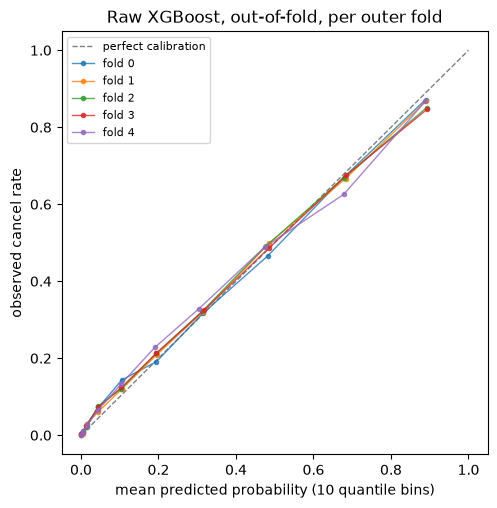

In [6]:
fig, ax = plt.subplots(figsize=(5.5, 5.5))
ax.plot([0, 1], [0, 1], ls='--', c='grey', lw=1, label='perfect calibration')
for k in range(5):
    m = fold == k
    frac, mean_p = calibration_curve(y[m], p_raw[m], n_bins=10, strategy='quantile')
    ax.plot(mean_p, frac, marker='o', ms=3, lw=1, alpha=0.8, label=f'fold {k}')
ax.set(xlabel='mean predicted probability (10 quantile bins)', ylabel='observed cancel rate',
       title='Raw XGBoost, out-of-fold, per outer fold')
ax.legend(fontsize=8)
plt.show()

All five fold curves lie close to the diagonal and on top of each other. Pooled over the ten quantile bins, the gap between observed and predicted is at most 0.03. The model is slightly **too cautious in the middle and low range** (for example, predicted 0.044 → observed 0.069; predicted 0.104 → observed 0.129). It is slightly **over-confident at the top** (predicted 0.891 → observed 0.861). This is the usual mild S-shape of a boosted-tree model, and it is small.

## 5. Cross-fitted isotonic and Platt calibrators

For fold k, each calibrator is fitted on the OOF probabilities and labels of the other four folds,
then applied to fold k's probabilities. **Isotonic** fits a free-form step function that never
decreases. **Platt** fits a logistic regression on the logit of p. Neither ever sees fold k's labels.

In [7]:
def logit(p):
    p = np.clip(p, 1e-6, 1 - 1e-6)
    return np.log(p / (1 - p))[:, None]

def fit_isotonic(p, y):
    return IsotonicRegression(out_of_bounds='clip', y_min=0, y_max=1).fit(p, y).predict

def fit_platt(p, y):
    lr = LogisticRegression(C=1e6, random_state=42).fit(logit(p), y)
    return lambda q: lr.predict_proba(logit(q))[:, 1]

p_cal = {'raw': p_raw, 'isotonic': np.zeros_like(p_raw), 'platt': np.zeros_like(p_raw)}
for name, fit in [('isotonic', fit_isotonic), ('platt', fit_platt)]:
    for k in range(5):
        m = fold == k
        p_cal[name][m] = fit(p_raw[~m], y[~m])(p_raw[m])

pd.DataFrame(p_cal).describe().round(4)

,raw,isotonic,platt
count,67974.0000,67974.0000,67974.0000
mean,0.2727,0.2774,0.2774
std,0.3013,0.2891,0.2879
min,0.0000,0.0000,0.0000
25%,0.0135,0.0238,0.0229
50%,0.1447,0.1606,0.1724
75%,0.4793,0.5026,0.4760
max,1.0000,1.0000,0.9999


Both calibrators pull the mean probability up to the cancel rate (0.2774), as expected from fitting on the labels of the other four folds. Isotonic maps p onto a step function, so many different raw scores collapse onto the same calibrated value. Platt keeps the ordering exactly.

In [8]:
calib = pd.DataFrame(index=pd.Index([str(k) for k in range(5)], name='outer_fold'))
for name, p in p_cal.items():
    calib[f'brier_{name}'] = per_fold(brier_score_loss, p)
for name, p in p_cal.items():
    calib[f'ap_{name}'] = per_fold(average_precision_score, p)
for name in ['isotonic', 'platt']:
    calib[f'd_{name}'] = calib.brier_raw - calib[f'brier_{name}']       # > 0 means the calibrator helped
    calib[f'ap_change_{name}'] = calib[f'ap_{name}'] - calib.ap_raw

calib_out = pd.concat([calib, calib.mean().to_frame('mean').T, calib.std(ddof=1).to_frame('sd').T])
calib_out.index.name = 'outer_fold'
calib_out.round(5)

,brier_raw,brier_isotonic,brier_platt,ap_raw,ap_isotonic,ap_platt,d_isotonic,ap_change_isotonic,d_platt,ap_change_platt
outer_fold,,,,,,,,,,
0,0.11638,0.11639,0.11630,0.77258,0.76407,0.77258,-0.00000,-0.00851,0.00008,0.0
1,0.11497,0.11487,0.11490,0.77270,0.76510,0.77270,0.00009,-0.00759,0.00006,0.0
2,0.11796,0.11776,0.11767,0.76076,0.75365,0.76076,0.00020,-0.00711,0.00029,0.0
3,0.11819,0.11781,0.11784,0.76116,0.75475,0.76116,0.00038,-0.00641,0.00034,0.0
4,0.12030,0.12011,0.11974,0.75468,0.74529,0.75468,0.00019,-0.00939,0.00056,0.0
mean,0.11756,0.11739,0.11729,0.76438,0.75657,0.76438,0.00017,-0.00780,0.00027,0.0
sd,0.00201,0.00194,0.00181,0.00797,0.00819,0.00797,0.00014,0.00117,0.00021,0.0


Both calibrators lower Brier by tiny amounts: isotonic by 0.00017 on average, Platt by 0.00027. That is about a tenth of the fold-to-fold spread of raw Brier (SD 0.0020). **Platt leaves AP exactly unchanged**, because a logistic map of the logit is strictly monotone. **Isotonic costs 0.0078 AP**, about one fold SD, because its flat steps create ties that break the ranking inside each step. So "AP barely changes" holds for Platt and does not hold for isotonic.

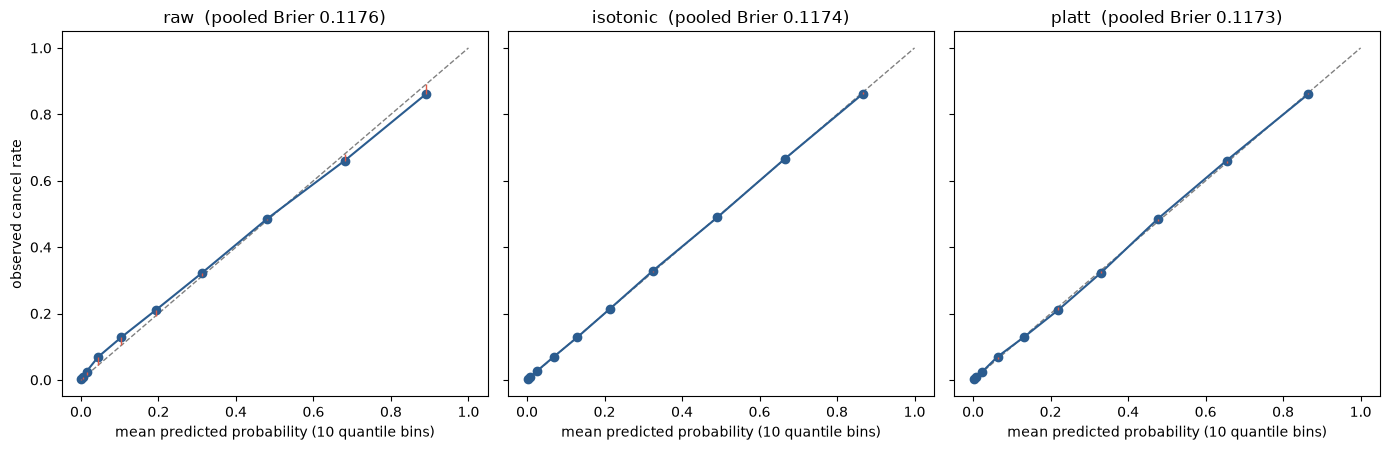

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4.6), sharey=True)
for ax, (name, p) in zip(axes, p_cal.items()):
    ax.plot([0, 1], [0, 1], ls='--', c='grey', lw=1)
    frac, mean_p = calibration_curve(y, p, n_bins=10, strategy='quantile')
    ax.plot(mean_p, frac, marker='o', c=palette[0])
    for mp, fr in zip(mean_p, frac):
        ax.vlines(mp, min(mp, fr), max(mp, fr), color=palette[1], lw=1)
    ax.set(title=f'{name}  (pooled Brier {brier_score_loss(y, p):.4f})',
           xlabel='mean predicted probability (10 quantile bins)')
axes[0].set_ylabel('observed cancel rate')
plt.tight_layout()
plt.show()

The three pooled curves are almost indistinguishable. The calibrators straighten the small low-range under-prediction and the top-bin over-confidence a little (red bars = gap to the diagonal), and pooled Brier moves only in the fourth decimal.

## 6. Stop/go: is a calibrator adopted?

Rule 9.1 is applied to Brier. A calibrator replaces raw probabilities only if the paired per-fold
reduction `d_k = Brier_raw,k − Brier_cal,k` has a **mean greater than the fold SD of raw Brier**
(ddof = 1) **and** is positive in **at least 4 of 5** folds.

In [10]:
bar_brier = calib.brier_raw.std(ddof=1)
calib_decision = pd.DataFrame({
    name: {'mean d_k': calib[f'd_{name}'].mean(),
           'bar (SD of raw Brier)': bar_brier,
           'folds with d_k > 0': int((calib[f'd_{name}'] > 0).sum()),
           'passes': bool(calib[f'd_{name}'].mean() > bar_brier and (calib[f'd_{name}'] > 0).sum() >= 4)}
    for name in ['isotonic', 'platt']}).T

passing = calib_decision[calib_decision.passes]
# if both pass, take the one with the larger mean reduction
calibrator = passing['mean d_k'].astype(float).idxmax() if len(passing) else 'none'
p_use = p_cal[calibrator] if calibrator != 'none' else p_raw
print('adopted calibrator:', calibrator)
calib_decision

adopted calibrator: none


,mean d_k,bar (SD of raw Brier),folds with d_k > 0,passes
isotonic,0.000172,0.00201,4,False
platt,0.000268,0.00201,5,False


**No calibrator is adopted.** Platt improves Brier in 5 of 5 folds and isotonic in 4 of 5, so the direction is consistent. But the mean reductions (0.00027 and 0.00017) are about an eighth of the 0.0020 bar. Raw XGBoost probabilities are kept. They are already well calibrated: Brier 0.1176, the largest bin gap is 0.03, and the mean probability is within 0.005 of the cancel rate. The R2 rule below is therefore run on raw p, which this evidence says is acceptable.

# Part 2 — The cost scenario (assumptions)

**These amounts are assumptions for illustration. They are not data from the hotels.** They make
the trade-off concrete, and section 10 shows how much the answer moves when they change.

- Flagging a booking triggers a contact action (a reminder, a deposit request or a confirmation call)
  that costs **c** euros per flagged booking, whether or not the booking cancels.
- If a flagged booking really cancels, the hotel recovers a fraction **r** of its value V, through
  earlier resale or controlled overbooking.
- Net saving from flagging booking i = `r · V_i · y_i − c`. Not flagging saves 0.
- Base case **c = €5, r = 0.25**. Sensitivity grid: c ∈ {2, 5, 10, 20} × r ∈ {0.10, 0.25, 0.50}.

## 7. What the base case is worth at the extremes

In [11]:
C_BASE, R_BASE = 5.0, 0.25

def saving(flag, y, V, c, r):
    # total euros saved by flagging the rows in `flag`
    return float(np.sum(flag * (r * V * y - c)))

extremes = pd.DataFrame({
    'flag nothing': 0.0,
    'flag everyone': saving(np.ones_like(y), y, V, C_BASE, R_BASE),
    # flags exactly the cancellations worth more than the contact cost
    'perfect foresight':saving((y == 1) & (R_BASE * V > C_BASE), y, V, C_BASE, R_BASE),
}, index=['saving per 1,000 bookings (€)']).T / len(y) * 1000
extremes.round(0)

,"saving per 1,000 bookings (€)"
flag nothing,0.0
flag everyone,28293.0
perfect foresight,31917.0


The base case turns out to be very generous to flagging. Contacting **every** booking already saves about **€28,300 per 1,000 bookings**, because the average cancellation is worth about €120 recovered against €5 spent. Perfect foresight would save about €31,900. So a model can add at most about €3,600 per 1,000 bookings over the blunt "contact everyone" policy, and the rules below are competing inside that narrow band.

# Part 3 — Decision rules

- **R1, global threshold (the reference):** flag if `p ≥ t`. t is picked from the grid 0.05, 0.06, …,
  0.95 to maximise total saving on the other four folds.
- **R2, value-aware:** flag if `p · r · V ≥ c`, which means the expected recovery covers the contact
  cost. It has nothing to tune, and it only makes sense if p is calibrated.
- **R3, F1-optimal threshold:** t on the same grid, chosen to maximise F1 on the other four folds.
  It is reported for comparison only, because F1 ignores the money.

All three use the probabilities chosen in section 6.

## 8. Cross-fitted rules at the base case

In [12]:
T_GRID = np.round(np.arange(0.05, 0.951, 0.01), 2)

def best_t(p, y, V, c, r):
    s = [saving(p >= t, y, V, c, r) for t in T_GRID]
    return T_GRID[int(np.argmax(s))]              # ties go to the lowest t

def best_t_f1(p, y):
    s = [f1_score(y, p >= t, zero_division=0) for t in T_GRID]
    return T_GRID[int(np.argmax(s))]

def score(flag, y, V, c, r):
    n = len(y)
    s = saving(flag, y, V, c, r)
    return {'n_rows': n, 'total_saving_eur': s, 'saving_per_1000': s / n * 1000,
            'pct_flagged': 100 * flag.mean(),
            'precision': precision_score(y, flag, zero_division=0),
            'recall': recall_score(y, flag, zero_division=0),
            'f1': f1_score(y, flag, zero_division=0)}

def evaluate_rules(p, c, r):
    rows = []
    for k in range(5):
        m, o = fold == k, fold != k
        t1 = best_t(p[o], y[o], V[o], c, r)
        t3 = best_t_f1(p[o], y[o])
        rows.append({'rule': 'R1', 'outer_fold': str(k), 'threshold': t1, **score(p[m] >= t1, y[m], V[m], c, r)})
        rows.append({'rule': 'R2', 'outer_fold': str(k), 'threshold': np.nan,
                     **score(p[m] * r * V[m] >= c, y[m], V[m], c, r)})
        rows.append({'rule': 'R3', 'outer_fold': str(k), 'threshold': t3, **score(p[m] >= t3, y[m], V[m], c, r)})
    return pd.DataFrame(rows)

rules = evaluate_rules(p_use, C_BASE, R_BASE)
summary = []
for rule, g in rules.groupby('rule'):
    num = g.drop(columns=['rule', 'outer_fold'])
    summary += [{'rule': rule, 'outer_fold': 'mean', **num.mean().to_dict()},
                {'rule': rule, 'outer_fold': 'sd', **num.std(ddof=1).to_dict()}]
decision_rules = pd.concat([rules, pd.DataFrame(summary)], ignore_index=True)
decision_rules.insert(2, 'c', C_BASE)
decision_rules.insert(3, 'r', R_BASE)
decision_rules.insert(4, 'calibrator', calibrator)
decision_rules.round(4)

,rule,outer_fold,c,r,calibrator,threshold,n_rows,total_saving_eur,saving_per_1000,pct_flagged,precision,recall,f1
0,R1,0,5.0,0.25,none,0.0500,13595.0000,420504.2050,30930.7985,63.5381,0.4230,0.9687,0.5889
1,R2,0,5.0,0.25,none,NaN,13595.0000,424465.0800,31222.1464,56.7562,0.4537,0.9282,0.6095
2,R3,0,5.0,0.25,none,0.3700,13595.0000,349908.0375,25737.9947,31.1585,0.6589,0.7399,0.6971
3,R1,1,5.0,0.25,none,0.0500,13594.0000,400522.4000,29463.1749,63.1896,0.4282,0.9751,0.5950
4,R2,1,5.0,0.25,none,NaN,13594.0000,403046.9325,29648.8843,56.1718,0.4629,0.9372,0.6197
5,R3,1,5.0,0.25,none,0.3600,13594.0000,336269.9050,24736.6415,31.5507,0.6617,0.7524,0.7041
6,R1,2,5.0,0.25,none,0.0500,13595.0000,400436.0675,29454.6574,63.6631,0.4250,0.9751,0.5919
7,R2,2,5.0,0.25,none,NaN,13595.0000,404332.9650,29741.2994,55.7999,0.4627,0.9305,0.6181
8,R3,2,5.0,0.25,none,0.3400,13595.0000,341093.8075,25089.6512,32.9754,0.6413,0.7622,0.6965
9,R1,3,5.0,0.25,none,0.0500,13595.0000,401151.8775,29507.3099,63.3542,0.4256,0.9719,0.5920


At the base case, **R1 picks t = 0.05 on every fold**. That is the lowest value the grid allows, so the true saving-maximising t is at or below the grid floor. It flags about 63% of bookings, catches 97% of cancellations at 43% precision, and saves **€29,601 ± 826 per 1,000 bookings**. That is about €1,300 more than contacting everyone. **R2** (flag if p·r·V ≥ c) flags fewer bookings (56%) at slightly higher precision and saves €29,853 ± 841. **R3**, the F1-optimal threshold (t ≈ 0.36), has the best F1 (0.696) but saves about €4,900 less per 1,000 bookings. F1 is the wrong target when a missed cancellation costs 24 times as much as a wasted contact.

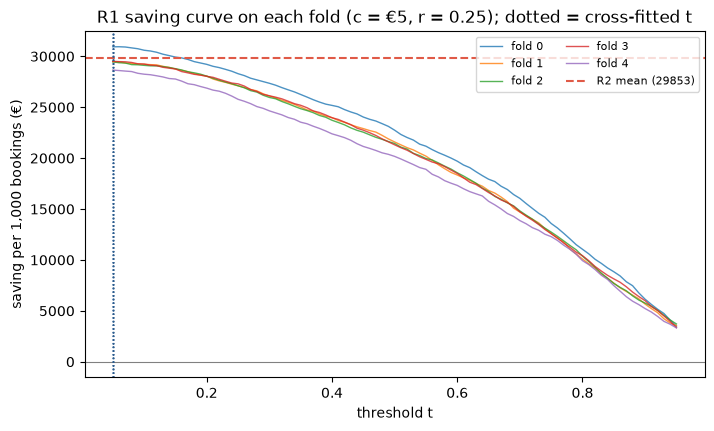

In [13]:
fig, ax = plt.subplots(figsize=(8, 4.5))
for k in range(5):
    m = fold == k
    s = [saving(p_use[m] >= t, y[m], V[m], C_BASE, R_BASE) / m.sum() * 1000 for t in T_GRID]
    ax.plot(T_GRID, s, lw=1, alpha=0.8, label=f'fold {k}')
r2 = rules[rules.rule == 'R2'].saving_per_1000.mean()
ax.axhline(r2, c=palette[1], ls='--', lw=1.5, label=f'R2 mean ({r2:.0f})')
ax.axhline(0, c='grey', lw=0.8)
for t in rules[rules.rule == 'R1'].threshold:
    ax.axvline(t, c=palette[0], ls=':', lw=1)
ax.set(xlabel='threshold t', ylabel='saving per 1,000 bookings (€)',
       title=f'R1 saving curve on each fold (c = €{C_BASE:g}, r = {R_BASE}); dotted = cross-fitted t')
ax.legend(fontsize=8, ncol=2)
plt.show()

On every fold the saving falls steadily as t rises, with no interior peak. The best threshold is the lowest one allowed, which is why every fold's cross-fitted t (dotted line) sits at 0.05. R2's mean (dashed) is just above the R1 curves' left end. Under these cost assumptions the decision is "contact almost everyone", and the model's job is to exclude the lowest-risk third of bookings.

## 9. Stop/go: does R2 replace R1?

`g_k = S_R2,k − S_R1,k`, where S is the saving per 1,000 bookings on fold k. R2 replaces R1 only if
mean `g_k` > the fold SD of `S_R1` (ddof = 1) **and** `g_k > 0` in at least 4 of 5 folds.

In [14]:
def stop_go(s_new, s_ref):
    g = s_new - s_ref
    bar = s_ref.std(ddof=1)
    return {'mean g_k': g.mean(), 'bar (SD of reference)': bar,
            'folds with g_k > 0': int((g > 0).sum()), 'passes': bool(g.mean() > bar and (g > 0).sum() >= 4)}

S = {rule: rules[rules.rule == rule].set_index('outer_fold').saving_per_1000 for rule in ['R1', 'R2', 'R3']}
rule_decision = pd.DataFrame({'R2 vs R1': stop_go(S['R2'], S['R1']),
                              'R3 vs R1 (comparison only)': stop_go(S['R3'], S['R1'])}).T
rule = 'R2' if rule_decision.loc['R2 vs R1', 'passes'] else 'R1'
print('frozen rule:', rule)
display(pd.DataFrame(S).T.assign(mean=lambda d: d.mean(axis=1), sd=lambda d: d.iloc[:, :5].std(axis=1, ddof=1)).round(1))
rule_decision

frozen rule: R1


outer_fold,0,1,2,3,4,mean,sd
R1,30930.8,29463.2,29454.7,29507.3,28647.2,29600.6,825.7
R2,31222.1,29648.9,29741.3,29741.4,28909.0,29852.5,841.5
R3,25738.0,24736.6,25089.7,24639.9,23378.4,24716.5,863.1


,mean g_k,bar (SD of reference),folds with g_k > 0,passes
R2 vs R1,251.910088,825.715685,5,False
R3 vs R1 (comparison only),-4884.12665,825.715685,0,False


**R1 stays.** R2 beats R1 in all 5 folds, but only by €252 per 1,000 bookings on average, against a bar of €826 (the fold SD of R1's saving). The gain is consistent in sign and small in size, the same pattern as the T2 ensembles. R3 loses to R1 in every fold, by about €4,900.

## 10. Sensitivity: does the answer hold across the cost grid?

For every (c, r) cell, R1 and R2 are re-run with the same cross-fitting, and the same stop/go picks
the cell's rule. That rule is then tested against **flagging nothing** (saving 0) with the same test:
the mean saving must be greater than its own fold SD, and positive in at least 4 of 5 folds. When
it fails, flagging nothing is the better choice for that cell.

In [15]:
cells = []
for c in [2, 5, 10, 20]:
    for r in [0.10, 0.25, 0.50]:
        ev = evaluate_rules(p_use, c, r)
        s1 = ev[ev.rule == 'R1'].saving_per_1000.to_numpy()
        s2 = ev[ev.rule == 'R2'].saving_per_1000.to_numpy()
        sg = stop_go(s2, s1)
        best = 'R2' if sg['passes'] else 'R1'
        s_best = s2 if best == 'R2' else s1
        g_best = ev[ev.rule == best]
        beats_nothing = s_best.mean() > s_best.std(ddof=1) and (s_best > 0).sum() >= 4
        cells.append({
            'c': c, 'r': r, 'best_rule': best,
            'r1_saving_per_1000_mean': s1.mean(), 'r1_saving_per_1000_sd': s1.std(ddof=1),
            'r2_saving_per_1000_mean': s2.mean(), 'r2_saving_per_1000_sd': s2.std(ddof=1),
            'r2_minus_r1_mean': sg['mean g_k'], 'r2_minus_r1_folds_positive': sg['folds with g_k > 0'],
            'best_saving_per_1000_mean': s_best.mean(), 'best_saving_per_1000_sd': s_best.std(ddof=1),
            'best_folds_positive': int((s_best > 0).sum()),
            'r1_threshold_folds': ' '.join(f'{t:.2f}' for t in ev[ev.rule == 'R1'].threshold),
            'r1_threshold_pooled': best_t(p_use, y, V, c, r),
            'best_pct_flagged_mean': g_best.pct_flagged.mean(),
            'flag_nothing_best': not beats_nothing,
        })
sensitivity = pd.DataFrame(cells)
sensitivity[['c', 'r', 'best_rule', 'r1_saving_per_1000_mean', 'r2_saving_per_1000_mean', 'r2_minus_r1_folds_positive',
             'best_saving_per_1000_mean', 'best_saving_per_1000_sd', 'r1_threshold_folds', 'r1_threshold_pooled',
             'best_pct_flagged_mean', 'flag_nothing_best']].round(2)

,c,r,best_rule,r1_saving_per_1000_mean,r2_saving_per_1000_mean,r2_minus_r1_folds_positive,best_saving_per_1000_mean,best_saving_per_1000_sd,r1_threshold_folds,r1_threshold_pooled,best_pct_flagged_mean,flag_nothing_best
0,2,0.10,R1,11840.25,11941.02,5,11840.25,330.29,0.05 0.05 0.05 0.05 0.05,0.05,63.48,False
1,2,0.25,R1,31505.17,31768.58,5,31505.17,824.95,0.05 0.05 0.05 0.05 0.05,0.05,63.48,False
2,2,0.50,R1,64280.03,64949.92,5,64280.03,1649.42,0.05 0.05 0.05 0.05 0.05,0.05,63.48,False
3,5,0.10,R1,10077.48,10359.01,5,10077.48,326.72,0.12 0.12 0.12 0.12 0.12,0.12,52.85,False
4,5,0.25,R1,29600.63,29852.54,5,29600.63,825.72,0.05 0.05 0.05 0.05 0.05,0.05,63.48,False
5,5,0.50,R1,62375.50,62843.81,5,62375.50,1650.16,0.05 0.05 0.05 0.05 0.05,0.05,63.48,False
6,10,0.10,R2,7649.27,8336.29,5,8336.29,366.63,0.20 0.22 0.22 0.20 0.25,0.22,33.94,False
7,10,0.25,R1,26459.11,27105.71,5,26459.11,827.01,0.12 0.07 0.08 0.07 0.12,0.08,56.74,False
8,10,0.50,R1,59201.27,59705.09,5,59201.27,1651.43,0.05 0.05 0.05 0.05 0.05,0.05,63.48,False
9,20,0.10,R2,4295.41,5602.16,5,5602.16,429.70,0.47 0.43 0.47 0.47 0.47,0.47,20.75,False


Across all 12 cost cells, **flagging nothing is never best**: every cell's winning rule saves money in 5 of 5 folds, far above its own fold SD. R1 stays the rule in 9 of 12 cells. R2 wins only where the contact cost is high relative to recovery (c = €10, r = 0.10; c = €20, r = 0.10 and 0.25). There the value-aware rule avoids contacting low-value bookings and gains up to €1,300 per 1,000 bookings over R1. R2's paired gain over R1 is positive in 5 of 5 folds in **every** cell, so R2 is never worse; it just rarely clears the bar. R1's pooled threshold is the grid floor 0.05 in 5 cells. It rises as c/r grows: 0.08 (c = €10, r = 0.25 and c = €20, r = 0.50), 0.12 (c = €5, r = 0.10), 0.20 (c = €20, r = 0.25), 0.22 (c = €10, r = 0.10) and 0.47 (c = €20, r = 0.10). **The threshold is driven by the cost assumptions far more than by the model.**

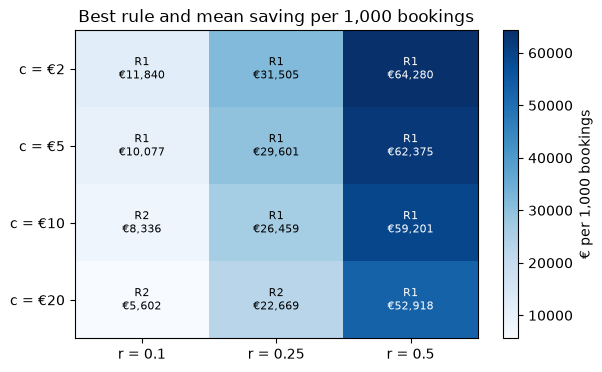

In [16]:
fig, ax = plt.subplots(figsize=(6.5, 4))
grid = sensitivity.pivot(index='c', columns='r', values='best_saving_per_1000_mean')
im = ax.imshow(grid.to_numpy(), cmap='Blues', aspect='auto')
for i, c in enumerate(grid.index):
    for j, r in enumerate(grid.columns):
        row = sensitivity[(sensitivity.c == c) & (sensitivity.r == r)].iloc[0]
        label = f"{row.best_rule}\n€{row.best_saving_per_1000_mean:,.0f}" + ('\n(flag nothing)' if row.flag_nothing_best else '')
        ax.text(j, i, label, ha='center', va='center', fontsize=8,
                color='white' if row.best_saving_per_1000_mean > grid.to_numpy().max() * 0.6 else 'black')
ax.set_xticks(range(len(grid.columns)), [f'r = {r:g}' for r in grid.columns])
ax.set_yticks(range(len(grid.index)), [f'c = €{c:g}' for c in grid.index])
ax.set_title('Best rule and mean saving per 1,000 bookings')
plt.colorbar(im, ax=ax, label='€ per 1,000 bookings')
plt.show()

Savings scale almost linearly with r and fall gently with c. The rule choice only flips to R2 in the bottom-left corner (expensive contact, low recovery). Everywhere else the simpler global threshold is as good as the value-aware rule within fold noise.

## 11. Freeze the decision

The frozen parameters are the calibrator (or none), the rule, and, for R1, one threshold t. For the
final model, t is chosen on the pooled OOF probabilities of all five folds, the same way each fold's t
was chosen on four. If a calibrator was adopted, T5 refits it on the pooled OOF probabilities.

In [17]:
base = rules[rules.rule == rule]
t_final = float(best_t(p_use, y, V, C_BASE, R_BASE)) if rule == 'R1' else None

frozen = {
    'task': 'T3',
    'notebook': 'notebooks/v2/12_calibration_threshold.ipynb',
    'model': 'xgboost',
    'oof_source': 'reports/results/v2/oof/xgboost.csv',
    'calibrator': calibrator,
    'calibrator_fit_for_final_model': 'none' if calibrator == 'none' else 'refit on pooled OOF probabilities of all 5 outer folds',
    'rule': rule,
    'rule_definition': 'flag if p >= threshold' if rule == 'R1' else 'flag if p * r * V >= c',
    'threshold': t_final,
    'threshold_grid': [float(T_GRID[0]), float(T_GRID[-1]), 0.01],
    'threshold_cross_fitted_per_fold': [float(t) for t in rules[rules.rule == 'R1'].threshold],
    'cost_assumptions': {
        'is_assumption': True,
        'c_eur_per_flag': C_BASE, 'r_recovered_fraction': R_BASE,
        'value_at_stake': 'V = adr * total_nights, floored at 0 (day-use V = 0)',
        'saving_if_flagged': 'r * V * y - c', 'saving_if_not_flagged': 0,
    },
    'cross_fitted_base_case': {
        'saving_per_1000_mean': float(base.saving_per_1000.mean()),
        'saving_per_1000_sd': float(base.saving_per_1000.std(ddof=1)),
        'pct_flagged_mean': float(base.pct_flagged.mean()),
        'precision_mean': float(base.precision.mean()),
        'recall_mean': float(base.recall.mean()),
        'f1_mean': float(base.f1.mean()),
    },
    'stop_go': {
        'calibration': {k: {kk: (bool(vv) if kk == 'passes' else float(vv)) for kk, vv in v.items()}
                        for k, v in calib_decision.to_dict('index').items()},
        'r2_vs_r1': {k: (bool(v) if k == 'passes' else float(v)) for k, v in rule_decision.loc['R2 vs R1'].items()},
    },
    'brier_raw_pooled': float(brier_score_loss(y, p_raw)),
    'sensitivity_cells_flag_nothing_best': int(sensitivity.flag_nothing_best.sum()),
    'sensitivity_cells_with_r2': int((sensitivity.best_rule == 'R2').sum()),
    'test_csv_read': False,
}

calib_out.to_csv(results / 'calibration.csv')
decision_rules.to_csv(results / 'decision_rules.csv', index=False)
sensitivity.to_csv(results / 'cost_sensitivity.csv', index=False)
(results / 'threshold.json').write_text(json.dumps(frozen, indent=2) + '\n')
print(json.dumps({k: frozen[k] for k in ['calibrator', 'rule', 'threshold', 'cost_assumptions', 'cross_fitted_base_case']}, indent=2))

{
  "calibrator": "none",
  "rule": "R1",
  "threshold": 0.05,
  "cost_assumptions": {
    "is_assumption": true,
    "c_eur_per_flag": 5.0,
    "r_recovered_fraction": 0.25,
    "value_at_stake": "V = adr * total_nights, floored at 0 (day-use V = 0)",
    "saving_if_flagged": "r * V * y - c",
    "saving_if_not_flagged": 0
  },
  "cross_fitted_base_case": {
    "saving_per_1000_mean": 29600.634618240972,
    "saving_per_1000_sd": 825.7156853421272,
    "pct_flagged_mean": 63.48456329006973,
    "precision_mean": 0.42523513234368593,
    "recall_mean": 0.9729586426299045,
    "f1_mean": 0.591814131191768
  }
}


Frozen for T5 in `reports/results/v2/threshold.json`: **no calibrator (raw XGBoost p), rule R1, threshold t = 0.05**, at the assumed c = €5 and r = 0.25. Cross-fitted, this saves €29,601 ± 826 per 1,000 bookings, flags 63% of bookings, and has precision 0.43, recall 0.97 and F1 0.59. The per-fold results are in `decision_rules.csv`, the calibrator comparison in `calibration.csv`, and the 12-cell grid in `cost_sensitivity.csv`.

## Summary

| Question | Answer |
| --- | --- |
| Are raw XGBoost probabilities calibrated? | Yes, closely. Pooled Brier 0.1176 (a constant guess scores 0.2005), the largest reliability-bin gap is 0.03, and the mean p is 0.2727 against a cancel rate of 0.2775 |
| Calibrator adopted? | **None.** Platt −0.00027 Brier (5/5 folds) and isotonic −0.00017 (4/5) are both far below the 0.0020 bar. Isotonic also costs 0.0078 AP |
| Frozen rule | **R1, flag if p ≥ 0.05**: €29,601 ± 826 saved per 1,000 bookings, 63% flagged, recall 0.97, precision 0.43 |
| R2 (value-aware) | Better in 5/5 folds by €252 per 1,000 bookings, against an €826 bar, so it is not adopted. It wins only in 3 of 12 cost cells (high c, low r) |
| R3 (F1-optimal, t ≈ 0.36) | Best F1 (0.70), but €4,900 per 1,000 bookings worse than R1 |
| Flag nothing ever best? | No, in none of the 12 cost cells |

**Limitation to carry into the report.** The costs are assumptions, and at the base case they make contacting a booking so cheap relative to what a cancellation is worth that the optimum sits at the grid floor. Contacting everyone would already capture most of the saving (about €28,300 of €29,600 per 1,000 bookings). The frozen t = 0.05 should be read as "contact everyone except the lowest-risk third". It is not a finely tuned cut-off, and it moves a lot with c and r (up to 0.47 in the sensitivity grid). The hotels' real contact cost and recovery rate would be needed before using it.